In [1]:
# adapted from https://gist.github.com/bafonso/d555c3beac66fd311c060761f634f247

import pandas as pd
import cudf

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from cuml.dask.common import utils as dask_utils
from dask.distributed import Client, wait
from dask_cuda import LocalCUDACluster
import dask_cudf

from cuml.dask.ensemble import RandomForestClassifier as cumlDaskRF

from warnings import filterwarnings
filterwarnings("ignore", category=UserWarning)

In [2]:
df = pd.read_parquet("../data/time_slices.parquet")
X = df.drop(["winner", "season", "game"], axis=1)
y = df["winner"].astype('category').cat.codes

# Train-test split using Dask
X_train, X_test, y_train, y_test = train_test_split(
    X.astype('float32'), y, train_size=0.8, random_state=42
)

In [3]:
# Start a Dask cluster using all GPUs available
cluster = LocalCUDACluster()
client = Client(cluster)

workers = client.has_what().keys()
n_workers = len(workers)
n_streams = 2

n_partitions = n_workers

In [4]:
def convert_label_to_int(dask_df):
    label_mapping = cudf.Series(dask_df.unique().compute()).reset_index().set_index(0)
    label_mapping_series = label_mapping['index']  # Extract the integer mapping
    return dask_df.map(label_mapping_series).astype("int32")

# First convert to cudf (with real data, you would likely load in cuDF format to start)
X_train_cudf = cudf.DataFrame.from_pandas(pd.DataFrame(X_train))
y_train_cudf = cudf.Series(y_train)
X_test_cudf = cudf.DataFrame.from_pandas(pd.DataFrame(X_test))
y_test_cudf = cudf.Series(y_test)

# Partition with Dask
# In this case, each worker will train on 1/n_partitions fraction of the data
X_train_dask = dask_cudf.from_cudf(X_train_cudf, npartitions=n_partitions)
y_train_dask = dask_cudf.from_cudf(y_train_cudf, npartitions=n_partitions)
y_train_dask = convert_label_to_int(y_train_dask)

X_test_dask = dask_cudf.from_cudf(X_test_cudf, npartitions=n_partitions)
y_test_dask = dask_cudf.from_cudf(y_test_cudf, npartitions=n_partitions)
y_test_dask = convert_label_to_int(y_test_dask)

# Persist to cache the data in active memory
X_train_dask, y_train_dask = \
  dask_utils.persist_across_workers(client, [X_train_dask, y_train_dask], workers=workers)

In [5]:
cuml_model = cumlDaskRF(
    n_bins=128,
    n_estimators=200,
    max_depth=12,
    max_features='sqrt',
    n_streams=1,
    client=client,
    bootstrap=True
)

cuml_model.fit(X_train_dask, y_train_dask)

wait(cuml_model.rfs)

DoneAndNotDoneFutures(done={<Future: finished, type: cuml.ensemble.randomforestclassifier.RandomForestClassifier, key: _construct_rf-d4d708f8-cee7-4682-8e30-92ec7d1b6895>}, not_done=set())

In [6]:
cuml_y_pred = cuml_model.predict(X_test_dask)

# for sklearn compatibility
cuml_y_pred_np = cuml_y_pred.compute().to_numpy()
y_test_np = y_test_dask.compute().to_numpy()

print("CuML accuracy:     ", accuracy_score(y_test_np, cuml_y_pred_np))

CuML accuracy:      0.8245318370624448


In [7]:
game = 30227
season = 2009
filtered_df = df[(df["game"] == game) & (df["season"] == season)]

# Drop unnecessary columns
X1 = filtered_df.drop(columns=["winner", "game", "season"], axis=1)

# Convert the DataFrame to float32 for more efficient GPU computation
X1 = X1.astype("float32")

# Convert the pandas DataFrame to CuDF DataFrame (ensure it's on the GPU)
X1_cudf = cudf.DataFrame.from_pandas(X1)

# Perform prediction using the cuML model (ensure input is a cudf DataFrame)
probabilities = cuml_model.predict_proba(dask_cudf.from_cudf(X1_cudf, npartitions=1))

probabilities_df = probabilities.compute().to_pandas()

print(probabilities_df)

               0         1
361118  0.564265  0.435735
361119  0.564265  0.435735
361120  0.564001  0.435999
361121  0.562291  0.437709
361122  0.562291  0.437709
...          ...       ...
361234  0.070597  0.929403
361235  0.070597  0.929403
361236  0.070597  0.929403
361237  0.070597  0.929403
361238  0.070597  0.929403

[121 rows x 2 columns]


In [8]:
from numpy import ndarray
import json
import matplotlib.pyplot as plt
import pandas as pd

def graphGame(time_remaining: pd.Series, probabilities: ndarray, home: tuple[str, str], away: tuple[str, str]):
    plt.figure(figsize=(10, 6))
    plt.plot(time_remaining, probabilities, color='black', linewidth=1)

    plt.fill_between(time_remaining, probabilities, 0, color=home[1], alpha=0.4, label=home[0])
    plt.fill_between(time_remaining, probabilities, 1, color=away[1], alpha=0.4, label=away[0])

    plt.xlim(0, 3600)
    plt.ylim(0, 1.0)
    plt.grid(False)
    plt.gca().invert_xaxis()
    plt.title("Home Team Win Probability Over Time")
    plt.xlabel("Time Remaining (s)")
    plt.ylabel("Win Probability")
    plt.legend()
    plt.grid()
    plt.show()

games = pd.read_parquet("../data/games.parquet")

# load teams and colors
with open("../analysis/teams.json") as f:
    teams = json.load(f)

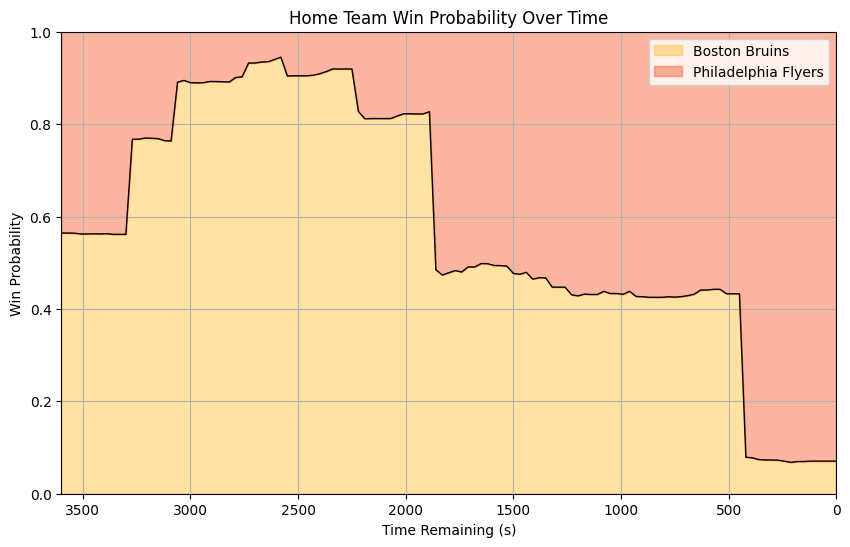

In [9]:
filtered_game = games[(games["Game_Id"] == str(game)) & (games["Season"] == season)]
for t in teams:
    idx = next(i for i, color in enumerate(t["colors"]["hex"]) if color != '010101')
    color = t["colors"]["hex"][idx]

    if t["team_code"] == filtered_game.iloc[0]["Home_Team"]:
        home = (t["name"], f'#{color}')
    elif t["team_code"] == filtered_game.iloc[0]["Away_Team"]:
        away = (t["name"], f'#{color}')

graphGame(filtered_df["time_remaining"] * 3600, probabilities_df.iloc[:, 0], home, away)